# User Engagement Analysis 
# 
As telecom brands are the data providers of all online activities, meeting user requirements, and creating an engaging user experience is a prerequisite for them. Building & improving the QoS (Quality of Service) to leverage the mobile platforms and to get more users for the business is good but the success of the business would be determined by the user engagement and activity of the customers on available apps. 
#
In telecommunication, tracking the user activities on the database sessions is a good starting point to appreciate the user engagement for the overall applications and per application as well. If we can determine the level of engagement of a random user for any application, then it could help the technical teams of the business to know where to concentrate network resources for different clusters of customers based on the engagement scores.

In the current dataset you’re expected to track the user’s engagement using the following engagement metrics: 

- sessions frequency 
- the duration of the session 
- the session total traffic (download and upload (bytes))

In [1]:
# Import Dataset and useful libraries 
import os 
import pandas as pd 
os.chdir('../scripts/')
import utils as util 


data_path = "../../data/week2/source.csv"
df = util.read_csv_file(data_path)
data = df.get("data")

In [7]:
data.columns

Index(['Bearer Id', 'Start', 'Start ms', 'End', 'End ms', 'Dur. (ms)', 'IMSI',
       'MSISDN/Number', 'IMEI', 'Last Location Name', 'Avg RTT DL (ms)',
       'Avg RTT UL (ms)', 'Avg Bearer TP DL (kbps)', 'Avg Bearer TP UL (kbps)',
       'TCP DL Retrans. Vol (Bytes)', 'TCP UL Retrans. Vol (Bytes)',
       'DL TP < 50 Kbps (%)', '50 Kbps < DL TP < 250 Kbps (%)',
       '250 Kbps < DL TP < 1 Mbps (%)', 'DL TP > 1 Mbps (%)',
       'UL TP < 10 Kbps (%)', '10 Kbps < UL TP < 50 Kbps (%)',
       '50 Kbps < UL TP < 300 Kbps (%)', 'UL TP > 300 Kbps (%)',
       'HTTP DL (Bytes)', 'HTTP UL (Bytes)', 'Activity Duration DL (ms)',
       'Activity Duration UL (ms)', 'Dur. (ms).1', 'Handset Manufacturer',
       'Handset Type', 'Nb of sec with 125000B < Vol DL',
       'Nb of sec with 1250B < Vol UL < 6250B',
       'Nb of sec with 31250B < Vol DL < 125000B',
       'Nb of sec with 37500B < Vol UL',
       'Nb of sec with 6250B < Vol DL < 31250B',
       'Nb of sec with 6250B < Vol UL < 37500B',


This section of the code is responsible for calculating user engagement metrics from the dataset. 
It groups the data by 'MSISDN/Number', which represents unique user identifiers, and aggregates several key metrics:
- session_frequency: counts the number of sessions for each user.
- total_duration: sums the total duration of all sessions in milliseconds for each user.
- total_traffic_dl: sums the total download traffic in bytes for each user.
- total_traffic_ul: sums the total upload traffic in bytes for each user.
After calculating these metrics, the code resets the index to create a clean DataFrame.
Additionally, it computes the total traffic by adding the download and upload traffic for each user.
Finally, the code identifies the top 10 customers based on each engagement metric: session frequency, total duration, and total traffic.
This information can be useful for understanding user engagement levels and identifying key users for targeted strategies.


In [3]:
engagement_metrics = data.groupby('MSISDN/Number').agg(
    session_frequency=('Start', 'count'),
    total_duration=('Dur. (ms)', 'sum'),
    total_traffic_dl=('Total DL (Bytes)', 'sum'),
    total_traffic_ul=('Total UL (Bytes)', 'sum')
).reset_index()

# Calculate total traffic
engagement_metrics['total_traffic'] = engagement_metrics['total_traffic_dl'] + engagement_metrics['total_traffic_ul']

# Get top 10 customers for each engagement metric
top_customers_frequency = engagement_metrics.nlargest(10, 'session_frequency')
top_customers_duration = engagement_metrics.nlargest(10, 'total_duration')
top_customers_traffic = engagement_metrics.nlargest(10, 'total_traffic')

top_customers_frequency, top_customers_duration, top_customers_traffic


(       MSISDN/Number  session_frequency  total_duration  total_traffic_dl  \
 13526   3.362632e+10                 18       8791927.0      7.301517e+09   
 6437    3.361489e+10                 17       9966898.0      8.156743e+09   
 13180   3.362578e+10                 17      18553754.0      7.770043e+09   
 37052   3.365973e+10                 16       4035428.0      7.081602e+09   
 76363   3.367588e+10                 15       4865947.0      7.309542e+09   
 92923   3.376054e+10                 15       9279434.0      7.811295e+09   
 65118   3.366716e+10                 13       8744914.0      5.052068e+09   
 666     3.360313e+10                 12       6287761.0      4.540607e+09   
 1279    3.360452e+10                 12       5207990.0      5.096079e+09   
 13994   3.362708e+10                 12       4703516.0      5.309479e+09   
 
        total_traffic_ul  total_traffic  
 13526       669650721.0   7.971167e+09  
 6437        689483001.0   8.846226e+09  
 13180       7

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Normalize the engagement metrics
scaler = StandardScaler()
normalized_metrics = scaler.fit_transform(engagement_metrics[['session_frequency', 'total_duration', 'total_traffic']])

# Run k-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
engagement_metrics['engagement_group'] = kmeans.fit_predict(normalized_metrics)

# Display the updated engagement metrics with the assigned groups
engagement_metrics.head()


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


,MSISDN/Number,session_frequency,total_duration,total_traffic_dl,total_traffic_ul,total_traffic,engagement_group
0,3.360100e+10,1,116720.0,8.426375e+08,36053108.0,8.786906e+08,0
1,3.360100e+10,1,181230.0,1.207552e+08,36104459.0,1.568596e+08,0
2,3.360100e+10,1,134969.0,5.566597e+08,39306820.0,5.959665e+08,0
3,3.360101e+10,1,49878.0,4.019932e+08,20327526.0,4.223207e+08,0
4,3.360101e+10,2,37104.0,1.363130e+09,94280527.0,1.457411e+09,1


   engagement_group  min_session_frequency  max_session_frequency  \
0                 0                      1                      2   
1                 1                      1                      4   
2                 2                      1                     18   

   avg_session_frequency  total_session_frequency  min_total_duration  \
0               1.028028                    82088              7142.0   
1               2.182744                    51205             18235.0   
2               4.409924                    15642             66594.0   

   max_total_duration  avg_total_duration  total_total_duration  \
0           1035261.0       103121.041127          8.234215e+09   
1           1480875.0       215264.264078          5.049884e+09   
2          18553754.0       658228.968424          2.334738e+09   

   min_total_traffic  max_total_traffic  avg_total_traffic  \
0         33249009.0       9.507607e+08       4.949519e+08   
1        177006936.0       2.512802e+

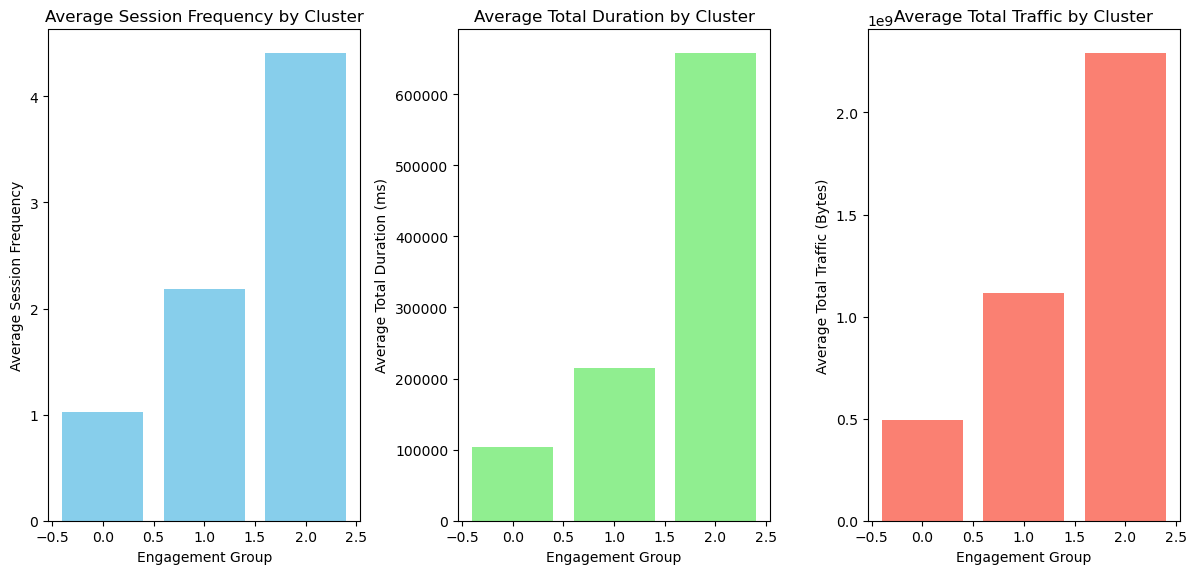

Cluster 0.0:
 - Min Session Frequency: 1.0, Max: 2.0, Avg: 1.0280275516593613, Total: 82088.0
 - Min Total Duration: 7142.0, Max: 1035261.0, Avg: 103121.04112711333, Total: 8234215134.0
 - Min Total Traffic: 33249009.0, Max: 950760661.0, Avg: 494951899.5784095, Total: 39521909181336.0


Cluster 1.0:
 - Min Session Frequency: 1.0, Max: 4.0, Avg: 2.1827443625047955, Total: 51205.0
 - Min Total Duration: 18235.0, Max: 1480875.0, Avg: 215264.26407775268, Total: 5049884371.0
 - Min Total Traffic: 177006936.0, Max: 2512802189.0, Avg: 1116121124.37346, Total: 26183085456677.0


Cluster 2.0:
 - Min Session Frequency: 1.0, Max: 18.0, Avg: 4.409923879334649, Total: 15642.0
 - Min Total Duration: 66594.0, Max: 18553754.0, Avg: 658228.9684240203, Total: 2334738151.0
 - Min Total Traffic: 370420998.0, Max: 8846226494.0, Avg: 2291641351.294051, Total: 8128451873040.0




In [5]:
# Compute non-normalized metrics for each cluster
cluster_metrics = engagement_metrics.groupby('engagement_group').agg(
    min_session_frequency=('session_frequency', 'min'),
    max_session_frequency=('session_frequency', 'max'),
    avg_session_frequency=('session_frequency', 'mean'),
    total_session_frequency=('session_frequency', 'sum'),
    min_total_duration=('total_duration', 'min'),
    max_total_duration=('total_duration', 'max'),
    avg_total_duration=('total_duration', 'mean'),
    total_total_duration=('total_duration', 'sum'),
    min_total_traffic=('total_traffic', 'min'),
    max_total_traffic=('total_traffic', 'max'),
    avg_total_traffic=('total_traffic', 'mean'),
    total_total_traffic=('total_traffic', 'sum')
).reset_index()

# Display the cluster metrics
print(cluster_metrics)

# Visualize the results
import matplotlib.pyplot as plt

# Plotting session frequency metrics
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.bar(cluster_metrics['engagement_group'], cluster_metrics['avg_session_frequency'], color='skyblue')
plt.title('Average Session Frequency by Cluster')
plt.xlabel('Engagement Group')
plt.ylabel('Average Session Frequency')

# Plotting total duration metrics
plt.subplot(1, 3, 2)
plt.bar(cluster_metrics['engagement_group'], cluster_metrics['avg_total_duration'], color='lightgreen')
plt.title('Average Total Duration by Cluster')
plt.xlabel('Engagement Group')
plt.ylabel('Average Total Duration (ms)')

# Plotting total traffic metrics
plt.subplot(1, 3, 3)
plt.bar(cluster_metrics['engagement_group'], cluster_metrics['avg_total_traffic'], color='salmon')
plt.title('Average Total Traffic by Cluster')
plt.xlabel('Engagement Group')
plt.ylabel('Average Total Traffic (Bytes)')

plt.tight_layout()
plt.show()

# Interpretation of results
for index, row in cluster_metrics.iterrows():
    print(f"Cluster {row['engagement_group']}:")
    print(f" - Min Session Frequency: {row['min_session_frequency']}, Max: {row['max_session_frequency']}, Avg: {row['avg_session_frequency']}, Total: {row['total_session_frequency']}")
    print(f" - Min Total Duration: {row['min_total_duration']}, Max: {row['max_total_duration']}, Avg: {row['avg_total_duration']}, Total: {row['total_total_duration']}")
    print(f" - Min Total Traffic: {row['min_total_traffic']}, Max: {row['max_total_traffic']}, Avg: {row['avg_total_traffic']}, Total: {row['total_total_traffic']}")
    print("\n")


In [9]:
# Assuming 'data' is the DataFrame containing user engagement data with columns for big tech companies
top_engaged_users = (
    data.groupby(['MSISDN/Number'])
    .agg(total_traffic=('Total DL (Bytes)', 'sum'), 
         total_traffic_ul=('Total UL (Bytes)', 'sum'),
         total_traffic_http=('HTTP DL (Bytes)', 'sum'),
         total_traffic_social_media=('Social Media DL (Bytes)', 'sum'),
         total_traffic_google=('Google DL (Bytes)', 'sum'),
         total_traffic_email=('Email DL (Bytes)', 'sum'),
         total_traffic_youtube=('Youtube DL (Bytes)', 'sum'),
         total_traffic_netflix=('Netflix DL (Bytes)', 'sum'),
         total_traffic_gaming=('Gaming DL (Bytes)', 'sum'),
         total_traffic_other=('Other DL (Bytes)', 'sum'))
    .reset_index()
)

# Get the top 10 most engaged users based on total traffic
top_10_engaged_users = top_engaged_users.sort_values('total_traffic', ascending=False).head(10)

# Display the results
print(top_10_engaged_users)


       MSISDN/Number  total_traffic  total_traffic_ul  total_traffic_http  \
6437    3.361489e+10   8.156743e+09       689483001.0          70195935.0   
92923   3.376054e+10   7.811295e+09       703478581.0          32862797.0   
13180   3.362578e+10   7.770043e+09       729577380.0            195754.0   
76363   3.367588e+10   7.309542e+09       581568792.0          99718963.0   
13526   3.362632e+10   7.301517e+09       669650721.0           1720802.0   
37052   3.365973e+10   7.081602e+09       624260321.0          32041442.0   
63028   3.366646e+10   6.903440e+09       405060976.0          23499971.0   
92577   3.376041e+10   6.610852e+09       521518890.0          54337630.0   
57241   3.366471e+10   6.400774e+09       471244453.0          23827993.0   
86455   3.369879e+10   6.010556e+09       530343105.0           5615644.0   

       total_traffic_social_media  total_traffic_google  total_traffic_email  \
6437                   27749744.0            93941708.0           336072

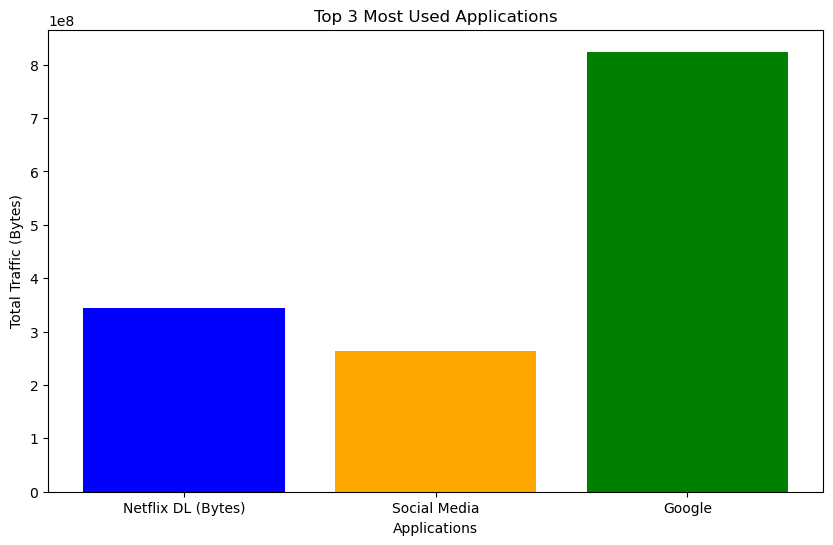

In [11]:
# Assuming 'top_10_engaged_users' DataFrame contains the total traffic for each application
applications = ['total_traffic_http', 'total_traffic_social_media', 'total_traffic_google']
app_names = ['Netflix DL (Bytes)', 'Social Media', 'Google']

# Create a new DataFrame for plotting
app_usage = top_10_engaged_users[applications].sum().reset_index()
app_usage.columns = ['Application', 'Total Traffic (Bytes)']

# Plotting the top 3 applications
plt.figure(figsize=(10, 6))
plt.bar(app_usage['Application'], app_usage['Total Traffic (Bytes)'], color=['blue', 'orange', 'green'])
plt.title('Top 3 Most Used Applications')
plt.xlabel('Applications')
plt.ylabel('Total Traffic (Bytes)')
plt.xticks(ticks=range(len(app_names)), labels=app_names)
plt.show()


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

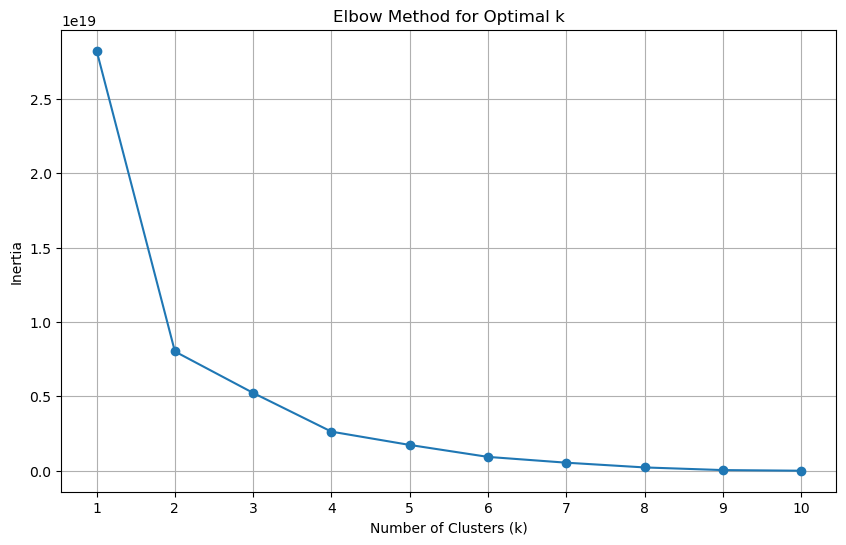

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


       MSISDN/Number  engagement_cluster
6437    3.361489e+10                   2
92923   3.376054e+10                   3
13180   3.362578e+10                   1
76363   3.367588e+10                   1
13526   3.362632e+10                   2
37052   3.365973e+10                   1
63028   3.366646e+10                   0
92577   3.376041e+10                   0
57241   3.366471e+10                   0
86455   3.369879e+10                   0


In [14]:
import os
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Set the environment variable to avoid memory leak warning
os.environ["OMP_NUM_THREADS"] = "1"

# Extract engagement metrics for clustering
engagement_metrics = top_10_engaged_users[['total_traffic', 'total_traffic_http', 
                                             'total_traffic_social_media', 
                                             'total_traffic_google', 
                                             'total_traffic_youtube', 
                                             'total_traffic_netflix', 
                                             'total_traffic_gaming', 
                                             'total_traffic_other']]

# Determine the optimal number of clusters using the elbow method
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)  # Set n_init explicitly
    kmeans.fit(engagement_metrics)
    inertia.append(kmeans.inertia_)

# Plotting the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid()
plt.show()

# Based on the elbow plot, choose the optimal k value (usually where the curve starts to flatten)
optimal_k = 4  # Example value, adjust based on the elbow plot

# Fit the KMeans model with the optimal k
kmeans = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)  # Set n_init explicitly
top_10_engaged_users['engagement_cluster'] = kmeans.fit_predict(engagement_metrics)

# Display the clustered data
print(top_10_engaged_users[['MSISDN/Number', 'engagement_cluster']])
